## Virtual Moving Test 2 (V2V) Plotting Results

In [1]:
import os, re
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

from datetime import datetime
import math
import pandas as pd
from itertools import chain

from utils import post_process_get_moving_test_data_and_timestamp
from utils import remove_outlier_by_quantile
from static_data_processing import get_test_files_and_survey
from plot_utils import *
from stats_utils import *

from pandas.core.common import SettingWithCopyWarning
import warnings
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

from collections import defaultdict

ROOT_DIR = os.path.join("C:/Users/wangz/OneDrive/University_RU/NSUWB/")
CALIBRATED_CAM_TO_V2B = -6400.8
pd.set_option('display.float_format', lambda x: '%.5f' % x)
pd.set_option('display.max_columns', None)

RESAMPLE_RULE = "1S"
PLOTTING_DPI = 75
static_main_master = 'D91E'
static_focusing_slaves = ['1912', '8D38']
static_master_slave_mapping = { 'D91E': [static_focusing_slaves[0], static_focusing_slaves[1]],
                                '0090': [static_focusing_slaves[1], static_focusing_slaves[0]]}
moving_main_master = '88BA'
moving_focusing_slaves = ['DB00', '069B']
moving_master_slave_mapping = { '88BA': [moving_focusing_slaves[0], moving_focusing_slaves[1]],
                                '111C': [moving_focusing_slaves[1], moving_focusing_slaves[0]]}
STATIC_VEH, MOVING_VEH = 3, 2
VEH_NAME_MAP = {3: "static", 2: "moving"}
test_preset_map = defaultdict(dict)
test_preset_map['PLOTTING_DPI'] = PLOTTING_DPI
test_preset_map['STATIC_VEH'] = STATIC_VEH
test_preset_map['MOVING_VEH'] = MOVING_VEH
test_preset_map[STATIC_VEH]['master_slave_mapping'] = static_master_slave_mapping
test_preset_map[MOVING_VEH]['master_slave_mapping'] = moving_master_slave_mapping
test_preset_map[STATIC_VEH]['main_master'] = static_main_master
test_preset_map[MOVING_VEH]['main_master'] = moving_main_master
test_preset_map['dist_interval_size'] = 1000
#############################################
# if skip plotting any tests, list them here
skiptests = []
#############################################
all_test_files, ground_truth_list = post_process_get_moving_test_data_and_timestamp(ROOT_DIR, 
                                                                                    "Moving Test 2 (Virtual Vehicle)", 
                                                                                    "V2", 
                                                                                    CALIBRATED_CAM_TO_V2B,
                                                                                    skiptests=skiptests)
assert(len(all_test_files) == len(ground_truth_list))
all_test_names_dup = [os.path.basename(os.path.dirname(f)) for f in all_test_files]
# Remove Duplicates of Test Names
all_test_names = []
_ = [all_test_names.append(x) for x in all_test_names_dup if x not in all_test_names]
test_raw_name_file_map = {}
for i in range(len(all_test_names)):
    test_raw_name_file_map[all_test_names[i]] = {}
    a_side_file, b_side_file = all_test_files[2*i], all_test_files[2*i+1]
    test_raw_name_file_map[all_test_names[i]]["A"] = a_side_file
    test_raw_name_file_map[all_test_names[i]]["B"] = b_side_file
    test_raw_name_file_map[all_test_names[i]]["ground_truth"] = ground_truth_list[2*i]
virtual_moving_tests = {}

## Parse and store the data for all the tests

In [2]:
virtual_moving_tests = {}
for test in all_test_names:
    virtual_moving_tests[test] = parse_single_test_data(test_raw_name_file_map[test]["B"],
                                                        "Virtual Moving Test",
                                                        test_preset_map,
                                                        test_raw_name_file_map[test]["ground_truth"])

processing: 2021-05-25-13-00-19-v2-1-west
processing: 2021-05-25-13-01-56-v2-1-east
2021-05-25-13-01-56-v2-1-east No Data
processing: 2021-05-25-13-07-12-v2-2-west-10mph
processing: 2021-05-25-13-09-08-v2-2-east-15mph
2021-05-25-13-09-08-v2-2-east-15mph No Data
processing: 2021-05-25-13-10-51-v2-3-west-10mph
2021-05-25-13-10-51-v2-3-west-10mph No Data
processing: 2021-05-25-13-12-45-v2-3-east-10mph
2021-05-25-13-12-45-v2-3-east-10mph No Data
processing: 2021-05-25-13-14-27-v2-4-west-20mph
processing: 2021-05-25-13-16-54-v2-4-east-20mph
2021-05-25-13-16-54-v2-4-east-20mph No Data
processing: 2021-05-25-13-24-09-v2-5-west-10mph
processing: 2021-05-25-13-27-19-v2-5-east-15mph
2021-05-25-13-27-19-v2-5-east-15mph No Data
processing: 2021-05-25-13-30-54-v2-6-west-15mph
2021-05-25-13-30-54-v2-6-west-15mph No Data
processing: 2021-05-25-13-33-14-v2-6-east-25mph
2021-05-25-13-33-14-v2-6-east-25mph No Data
processing: 2021-05-25-13-39-32-v2-7-west-edgepush
processing: 2021-05-25-13-42-27-v2-edge

## Virtual Moving Test 2 Overall Stats, Downtime

In [3]:
# Global Statistics
static_stats_list_pairwise = []
static_stats_list_aggregated = []
moving_stats_list_pairwise = []
moving_stats_list_aggregated = []

# Combination of All, Indexed by Time
list_df_time_idx_static = []
list_df_time_idx_moving = []

# Combination of All, Indexed by Ground Truth Distances
list_df_dist_idx_static = []
list_df_dist_idx_moving = []

# Combination of All, Indexed by Instance Speed by Markers
list_df_spd_idx_static = []
list_df_spd_idx_moving = []

for raw_name in all_test_names:
    parsing_results = virtual_moving_tests.get(raw_name)
    if not parsing_results:
        continue
    # Unpack dataframes
    df_outlier_overall = parsing_results["df_outlier_overall"]
    moving_ground_truth_df = parsing_results["moving_ground_truth_df"]
    for veh in parsing_results["vehicles"]:
        df_veh_time_idx = parsing_results[veh]["df_veh_time_idx"]
        df_veh_dist_idx = parsing_results[veh]["df_veh_dist_idx"]
        df_veh_spd_idx = parsing_results[veh]["df_veh_spd_idx"]
        veh_err_bins = parsing_results[veh]["veh_err_bins"]
        df_stats_pairwise = parsing_results[veh]['df_stats_pairwise']
        df_stats_aggregated = parsing_results[veh]['df_stats_aggregated']
        if veh == STATIC_VEH:
            df_static_time_idx, static_bins = df_veh_time_idx, veh_err_bins
            list_df_time_idx_static.append(df_veh_time_idx)
            list_df_dist_idx_static.append(df_veh_dist_idx)
            list_df_spd_idx_static.append(df_veh_spd_idx)
            static_stats_list_pairwise.append(df_stats_pairwise)
            static_stats_list_aggregated.append(df_stats_aggregated)
        elif veh == MOVING_VEH:
            df_moving_time_idx, moving_bins = df_veh_time_idx, veh_err_bins
            list_df_time_idx_moving.append(df_veh_time_idx)
            list_df_dist_idx_moving.append(df_veh_dist_idx)
            list_df_spd_idx_moving.append(df_veh_spd_idx)
            moving_stats_list_pairwise.append(df_stats_pairwise)
            moving_stats_list_aggregated.append(df_stats_aggregated)
    
df_all_static_stats_pairwise = pd.concat(static_stats_list_pairwise, ignore_index=True)
df_all_static_stats_aggregated = pd.concat(static_stats_list_aggregated, ignore_index=True)
df_all_static_stats_aggregated["Main Pair Counts"] = np.array(
    df_all_static_stats_pairwise[(df_all_static_stats_pairwise["Is Main Master"]==True) & 
                                             (df_all_static_stats_pairwise["Is Main Slave"]==True)
                                            ]["Reporting Counts"])
df_all_moving_stats_pairwise = pd.concat(moving_stats_list_pairwise, ignore_index=True)
df_all_moving_stats_aggregated = pd.concat(moving_stats_list_aggregated, ignore_index=True)
df_all_moving_stats_aggregated["Main Pair Counts"] = np.array(
    df_all_moving_stats_pairwise[(df_all_moving_stats_pairwise["Is Main Master"]==True) & 
                                             (df_all_moving_stats_pairwise["Is Main Slave"]==True)
                                            ]["Reporting Counts"])

df_all_static_stats_dist_idx = pd.concat(list_df_dist_idx_static)
df_all_static_stats_time_idx = pd.concat(list_df_time_idx_static)
df_all_static_stats_spd_idx = pd.concat(list_df_spd_idx_static)
df_all_moving_stats_dist_idx = pd.concat(list_df_dist_idx_moving)
df_all_moving_stats_time_idx = pd.concat(list_df_time_idx_moving)
df_all_moving_stats_spd_idx = pd.concat(list_df_spd_idx_moving)


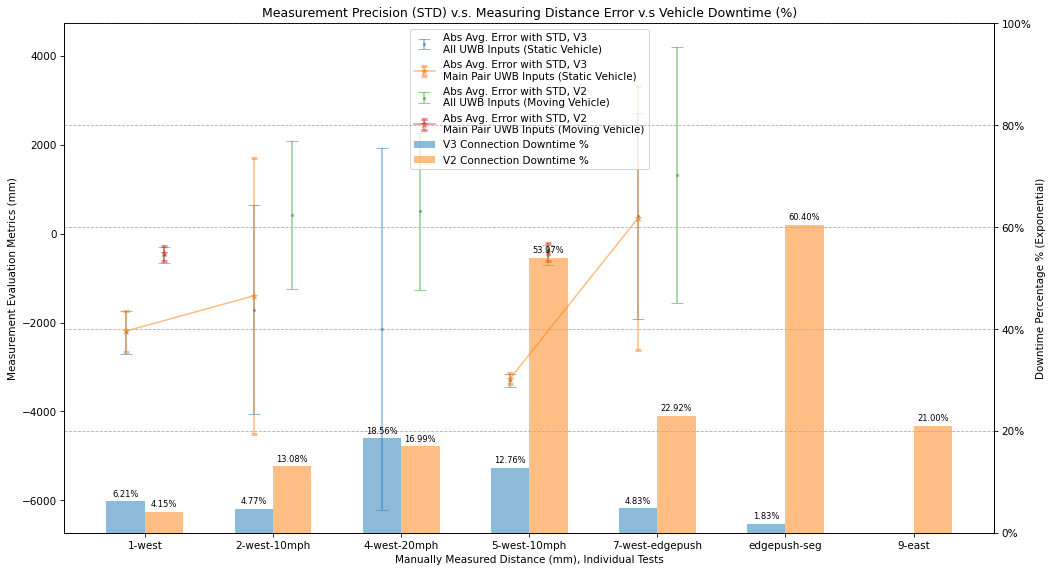

In [4]:
from matplotlib.ticker import FuncFormatter
figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
width=0.3
labels_static = df_all_static_stats_aggregated["Test Name"].astype(str)
labels_moving = df_all_moving_stats_aggregated["Test Name"].astype(str)
ax = figure.add_subplot(111)
ax.set_title("Measurement Precision (STD) v.s. Measuring Distance Error v.s Vehicle Downtime (%)")
df_main_pair_static_veh_stats_moving_test = df_all_static_stats_pairwise[
    (df_all_static_stats_pairwise["Is Main Master"]==True) & 
    (df_all_static_stats_pairwise["Is Main Slave"]==True)]
df_main_pair_moving_veh_stats_moving_test = df_all_moving_stats_pairwise[
    (df_all_moving_stats_pairwise["Is Main Master"]==True) & 
    (df_all_moving_stats_pairwise["Is Main Slave"]==True)]
errbar_1 = ax.errorbar(x=np.arange(len(labels_static.index)) - width/2,
                       y=df_all_static_stats_aggregated["Average Measurement Error (mm)"],
                       yerr=df_all_static_stats_aggregated["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Static Vehicle)'.format(STATIC_VEH))
errbar_1_1 = ax.errorbar(x=np.arange(len(labels_static.index)) - width/2,
                         y=df_main_pair_static_veh_stats_moving_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_static_veh_stats_moving_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Static Vehicle)'.format(STATIC_VEH))
errbar_2 = ax.errorbar(x=np.arange(len(labels_moving.index)) + width/2,
                       y=df_all_moving_stats_aggregated["Average Measurement Error (mm)"],
                       yerr=df_all_moving_stats_aggregated["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Moving Vehicle)'.format(MOVING_VEH))
errbar_2_1 = ax.errorbar(x=np.arange(len(labels_moving.index)) + width/2,
                         y=df_main_pair_moving_veh_stats_moving_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_moving_veh_stats_moving_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Moving Vehicle)'.format(MOVING_VEH))
labels = labels_static if len(labels_static) >= len(labels_moving) else labels_moving 
ax.set_xlabel("Manually Measured Distance (mm), Individual Tests")
ax.set_xticks(np.arange(len(labels.index)))
ax.set_xticklabels([x.split("-v2-")[1] for x in list(labels)])
ax.set_ylabel("Measurement Evaluation Metrics (mm)")

ax2 = ax.twinx()
rects1 = ax2.bar(np.arange(len(labels_static.index)) - width/2,
                 df_all_static_stats_aggregated["Downtime Duration"] / \
                 df_all_static_stats_aggregated["Operation Duration"],
                 width=width, label='V{} Connection Downtime %'.format(STATIC_VEH), alpha=0.5)
rects2 = ax2.bar(np.arange(len(labels_moving.index)) + width/2,
                 df_all_moving_stats_aggregated["Downtime Duration"] / \
                 df_all_moving_stats_aggregated["Operation Duration"],
                 width=width, label='V{} Connection Downtime %'.format(MOVING_VEH), alpha=0.5)
ax2.set_xticks(np.arange(len(labels.index)))
ax2.set_xticklabels([x.split("-v2-")[1] for x in list(labels)])
ax2.set_ylabel("Downtime Percentage % (Exponential)")
ax2.set_ylim([0, 1])
ax2.bar_label(rects1, padding=3, labels=['{:.2%}'.format(x).lstrip('0') for x in rects1.datavalues], fontsize=8)
ax2.bar_label(rects2, padding=3, labels=['{:.2%}'.format(x).lstrip('0') for x in rects2.datavalues], fontsize=8)
ax2.grid(axis='y', linestyle='--')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

ax.legend([errbar_1, errbar_1_1, errbar_2, errbar_2_1, rects1, rects2], 
          [errbar_1.get_label(), errbar_1_1.get_label(), errbar_2.get_label(), errbar_2_1.get_label(),
          rects1.get_label(), 
          rects2.get_label()],
          loc="upper center")

plt.show()

## Virtual Moving Test 2 Overall Stats, Reporting Counts

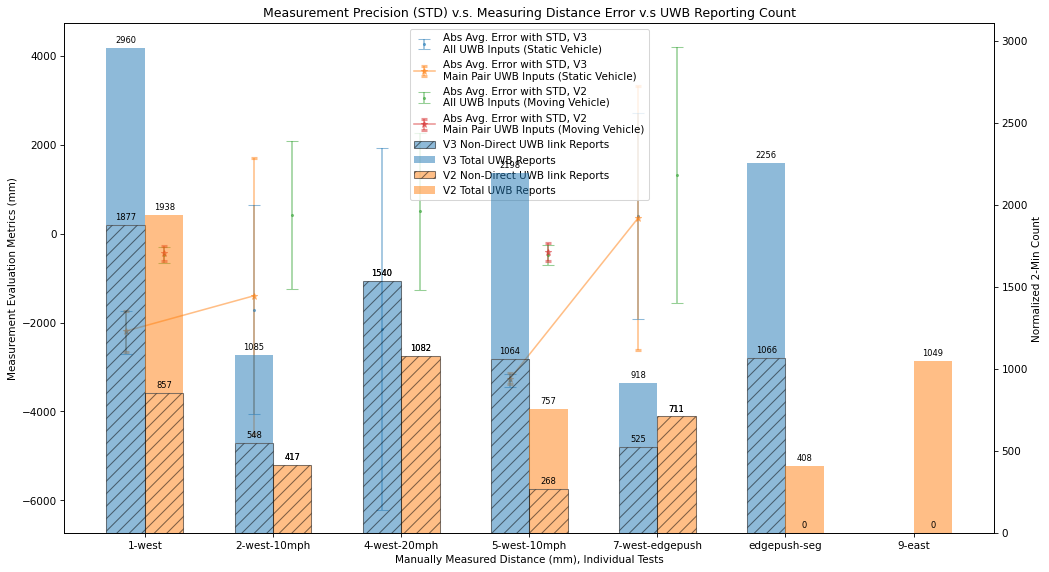

In [5]:
from matplotlib.ticker import FuncFormatter
figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
width=0.3
labels_static = df_all_static_stats_aggregated["Test Name"].astype(str)
labels_moving = df_all_moving_stats_aggregated["Test Name"].astype(str)
ax = figure.add_subplot(111)
ax.set_title("Measurement Precision (STD) v.s. Measuring Distance Error v.s UWB Reporting Count")
df_main_pair_static_veh_stats_moving_test = df_all_static_stats_pairwise[
    (df_all_static_stats_pairwise["Is Main Master"]==True) & 
    (df_all_static_stats_pairwise["Is Main Slave"]==True)]
df_main_pair_moving_veh_stats_moving_test = df_all_moving_stats_pairwise[
    (df_all_moving_stats_pairwise["Is Main Master"]==True) & 
    (df_all_moving_stats_pairwise["Is Main Slave"]==True)]
errbar_1 = ax.errorbar(x=np.arange(len(labels_static.index)) - width/2,
                       y=df_all_static_stats_aggregated["Average Measurement Error (mm)"],
                       yerr=df_all_static_stats_aggregated["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Static Vehicle)'.format(STATIC_VEH))
errbar_1_1 = ax.errorbar(x=np.arange(len(labels_static.index)) - width/2,
                         y=df_main_pair_static_veh_stats_moving_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_static_veh_stats_moving_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Static Vehicle)'.format(STATIC_VEH))
errbar_2 = ax.errorbar(x=np.arange(len(labels_moving.index)) + width/2,
                       y=df_all_moving_stats_aggregated["Average Measurement Error (mm)"],
                       yerr=df_all_moving_stats_aggregated["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Moving Vehicle)'.format(MOVING_VEH))
errbar_2_1 = ax.errorbar(x=np.arange(len(labels_moving.index)) + width/2,
                         y=df_main_pair_moving_veh_stats_moving_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_moving_veh_stats_moving_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Moving Vehicle)'.format(MOVING_VEH))
labels = labels_static if len(labels_static) >= len(labels_moving) else labels_moving 
ax.set_xlabel("Manually Measured Distance (mm), Individual Tests")
ax.set_xticks(np.arange(len(labels.index)))
ax.set_xticklabels([x.split("-v2-")[1] for x in list(labels)])
ax.set_ylabel("Measurement Evaluation Metrics (mm)")

ax2 = ax.twinx()

rects1 = ax2.bar(np.arange(len(labels_static.index)) - width/2,
                (df_all_static_stats_aggregated["Main Pair Counts"] /
                 df_all_static_stats_aggregated["Operation Duration"]*120).astype("int"), 
                 bottom=((df_all_static_stats_aggregated["Reporting Counts"] - 
                         df_all_static_stats_aggregated["Main Pair Counts"]) /
                        df_all_static_stats_aggregated["Operation Duration"]*120).astype("int"),
                 width=width, 
                 label='V{} Total UWB Reports'.format(STATIC_VEH), alpha=0.5, color="C0")
rects0 = ax2.bar(np.arange(len(labels_static.index)) - width/2,
                ((df_all_static_stats_aggregated["Reporting Counts"] - 
                  df_all_static_stats_aggregated["Main Pair Counts"]) / 
                 df_all_static_stats_aggregated["Operation Duration"]*120).astype("int"),
                 width=width, 
                 label='V{} Non-Direct UWB link Reports'.format(STATIC_VEH), 
                 alpha=0.5, color="C0", hatch="//", edgecolor='k')


rects3 = ax2.bar(np.arange(len(labels_moving.index)) + width/2,
                (df_all_moving_stats_aggregated["Main Pair Counts"] / 
                 df_all_moving_stats_aggregated["Operation Duration"]*120).astype("int"), 
                 bottom=((df_all_moving_stats_aggregated["Reporting Counts"] - 
                         df_all_moving_stats_aggregated["Main Pair Counts"]) / 
                        df_all_moving_stats_aggregated["Operation Duration"]*120).astype("int"),
                 width=width, 
                 label='V{} Total UWB Reports'.format(MOVING_VEH), alpha=0.5, color="C1")
rects2 = ax2.bar(np.arange(len(labels_moving.index)) + width/2,
                ((df_all_moving_stats_aggregated["Reporting Counts"] - 
                  df_all_moving_stats_aggregated["Main Pair Counts"]) / 
                 df_all_moving_stats_aggregated["Operation Duration"]*120).astype("int"),
                 width=width, 
                 label='V{} Non-Direct UWB link Reports'.format(MOVING_VEH), 
                 alpha=0.5, color="C1", hatch="//", edgecolor='k')

ax2.set_ylabel("Normalized 2-Min Count")
ax2.bar_label(rects1, padding=3, fontsize=8)
ax2.bar_label(rects0, padding=3, fontsize=8)
ax2.bar_label(rects3, padding=3, fontsize=8)
ax2.bar_label(rects2, padding=3, fontsize=8)
ax.legend([errbar_1, errbar_1_1, errbar_2, errbar_2_1, 
           rects0, rects1, rects2, rects3], 
          [errbar_1.get_label(), errbar_1_1.get_label(), errbar_2.get_label(), errbar_2_1.get_label(), 
           rects0.get_label(), rects1.get_label(), rects2.get_label(), rects3.get_label()],
          loc="upper center")
plt.show()

## Virtual Moving Test 2 Overall Error Distribution

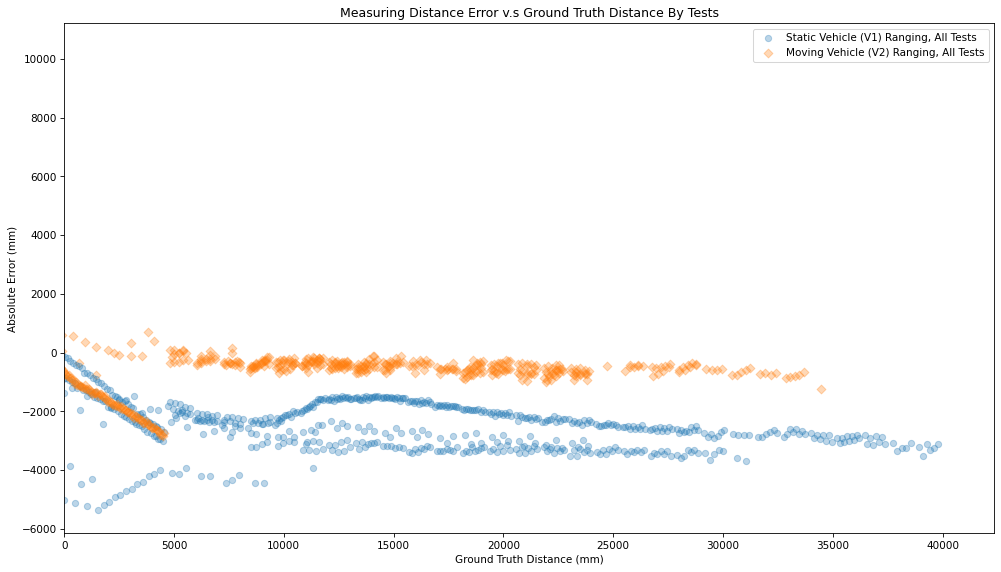

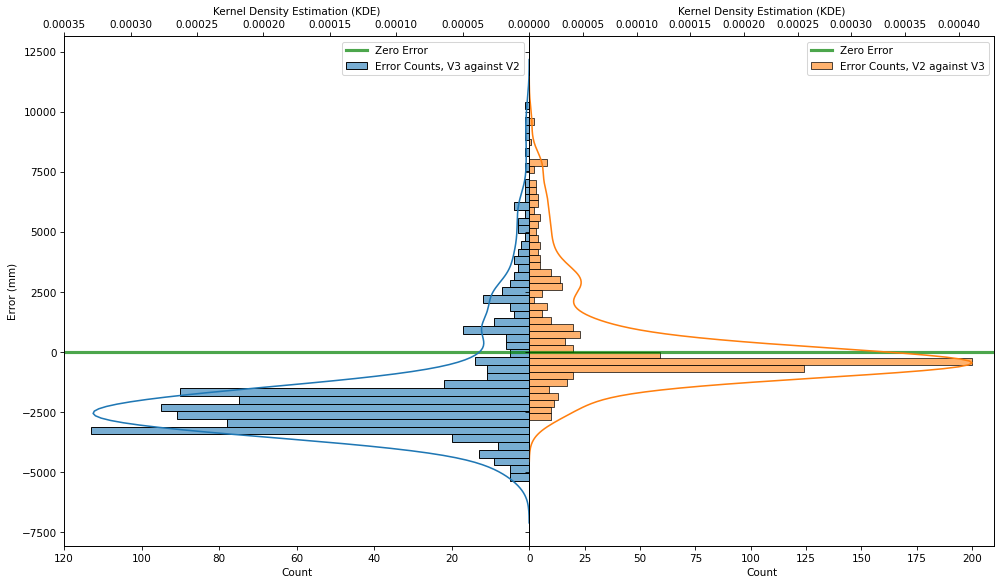

In [6]:
figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
ax = figure.add_subplot(111)
ax.set_title("Measuring Distance Error v.s Ground Truth Distance By Tests")
labels = df_all_static_stats_dist_idx["Test Name"].astype(str)
i = 0
for test in list(labels.unique()):
    _test_df_static = df_all_static_stats_dist_idx[
        df_all_static_stats_dist_idx["Test Name"] == test]
    _test_df_moving = df_all_moving_stats_dist_idx[
        df_all_moving_stats_dist_idx["Test Name"] == test]
    if i > 0:
        ax.scatter(_test_df_static.index, _test_df_static["Correction Distance (mm)"] - _test_df_static.index, 
                   alpha=0.3, marker="o", color="C0")
        ax.scatter(_test_df_moving.index, _test_df_moving["Correction Distance (mm)"] - _test_df_moving.index, 
                   alpha=0.3, marker="D", color="C1")
    else:
        ax.scatter(_test_df_static.index, _test_df_static["Correction Distance (mm)"] - _test_df_static.index, 
                   alpha=0.3, marker="o", color="C0", 
                   label = "Static Vehicle (V1) Ranging, All Tests")
        ax.scatter(_test_df_moving.index, _test_df_moving["Correction Distance (mm)"] - _test_df_moving.index, 
                   alpha=0.3, marker="D", color="C1", 
                   label = "Moving Vehicle (V2) Ranging, All Tests")
    i += 1
ax.set_xlabel("Ground Truth Distance (mm)")
ax.set_xlim(left=0)
ax.set_ylabel("Absolute Error (mm)")
ax.legend()

# Horizontal Histgram
figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
axs = figure.subplots(1,2,sharey=True)
figure.subplots_adjust(wspace=0)
ax_static, ax_moving = axs[0], axs[1]
ax2_static, ax2_moving = axs[0].twiny(), axs[1].twiny()

my_palette = sns.color_palette("muted")

zero_static = ax_static.axhline(y=0, color="g", label="Zero Error", linewidth=3, alpha=0.7)
_data_static = ((df_all_static_stats_dist_idx["Correction Distance (mm)"] 
                - df_all_static_stats_dist_idx.index)
                .reset_index()
                .rename(columns={0 :'Error (mm)'}))
hist_static = sns.histplot(
    data=_data_static,
    y='Error (mm)',
    alpha =0.6,
    label="Error Counts, V{} against V{}".format(STATIC_VEH, MOVING_VEH),
    ax=ax_static,
    color="C0"
)

kde_static = sns.kdeplot(
    data=_data_static,
    x='Error (mm)',
    ax=ax2_static,
    label="Kernel Density Distribution, V{} against V{}".format(STATIC_VEH, MOVING_VEH), 
    linewidth=1.5,
    vertical=True,
    color="C0")

zero_moving = ax_moving.axhline(y=0, color="g", label="Zero Error", linewidth=3, alpha=0.7)
_data_moving = ((df_all_moving_stats_dist_idx["Correction Distance (mm)"] 
                - df_all_moving_stats_dist_idx.index)
                .reset_index()
                .rename(columns={0 :'Error (mm)'}))
hist_moving = sns.histplot(
    data=_data_moving,
    y='Error (mm)',
    alpha =0.6,
    label="Error Counts, V{} against V{}".format(MOVING_VEH, STATIC_VEH),
    ax=ax_moving,
    color="C1"
)
kde_moving = sns.kdeplot(
    data=_data_moving,
    x='Error (mm)',
    ax=ax2_moving, 
    label="Kernel Density Distribution, V{} against V{}".format(MOVING_VEH, STATIC_VEH), 
    linewidth=1.5,
    vertical=True, 
    color="C1")

ax_static.set_xlim(ax_static.get_xlim()[::-1])
ax2_static.set_xlim(ax2_static.get_xlim()[::-1])

ax2_static.set_xlabel("Kernel Density Estimation (KDE)")
ax2_moving.set_xlabel("Kernel Density Estimation (KDE)")

ax_static.set_xticks(ax_static.get_xticks()[1:])
ax2_static.set_xticks(ax2_static.get_xticks()[1:])

axs[0].legend()
axs[1].legend()
plt.show()

## Virtual Moving Test 2 Update Rate v.s. Locations, Scatter

### Static Vehicle & Moving Vehicle

C:\Users\wangz\.conda\envs\py37iot\lib\site-packages\ipykernel_launcher.py:68: UserWarning: FixedFormatter should only be used together with FixedLocator
C:\Users\wangz\.conda\envs\py37iot\lib\site-packages\ipykernel_launcher.py:68: UserWarning: FixedFormatter should only be used together with FixedLocator


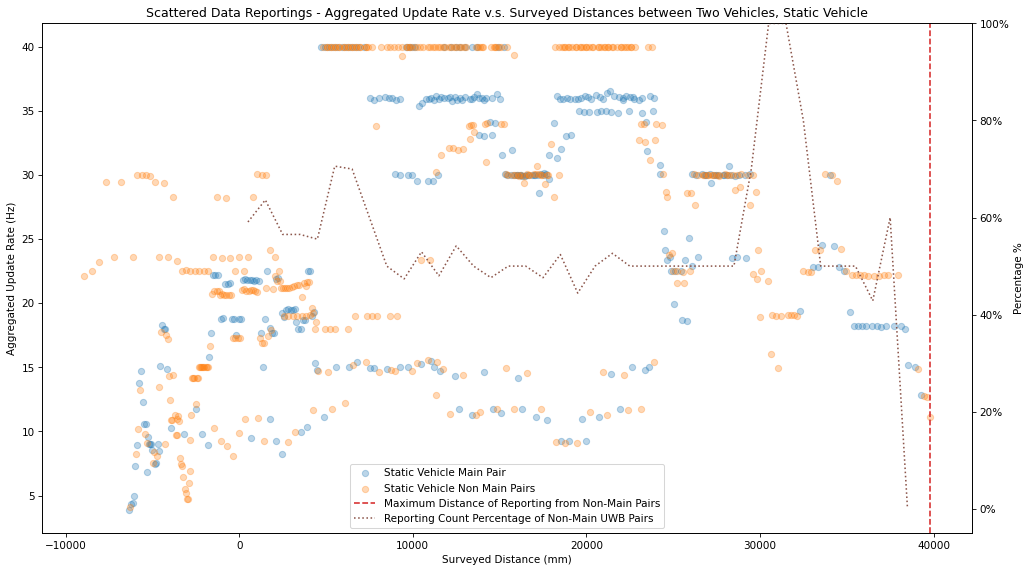

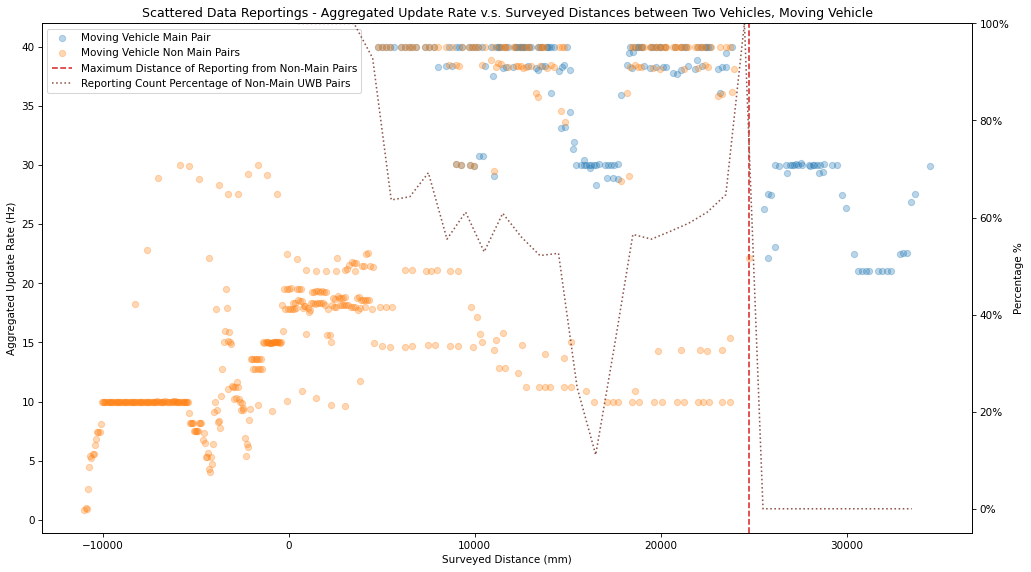

In [7]:
binsize = 1000

for df_veh_dist_idx_all_tests in [df_all_static_stats_dist_idx, df_all_moving_stats_dist_idx]:
    if df_veh_dist_idx_all_tests['Initiating Vehicle'].unique()[0] == STATIC_VEH:
        veh_name = "Static"
    if df_veh_dist_idx_all_tests['Initiating Vehicle'].unique()[0] == MOVING_VEH:
        veh_name = "Moving"
    figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
    ax = figure.add_subplot(111)
    main_df = df_veh_dist_idx_all_tests[
        (df_veh_dist_idx_all_tests["Is Main Master"] == True) & 
        (df_veh_dist_idx_all_tests["Is Main Slave"] == True)
    ]
    main_df = main_df[main_df.index.notnull()]

    non_main_df = df_veh_dist_idx_all_tests[
        (df_veh_dist_idx_all_tests["Is Main Master"] != True) | 
        (df_veh_dist_idx_all_tests["Is Main Slave"] != True)
    ]
    non_main_df = non_main_df[non_main_df.index.notnull()]

    # Aggregated
    main_scatter = ax.scatter(main_df.index, 
                            main_df["Aggregated Update Rate (Hz)"], 
                            label="{} Vehicle Main Pair".format(veh_name),
                            color="C0",
                            alpha=0.3)
            
    # Aggregated
    non_main_scatter = ax.scatter(non_main_df.index, 
                                non_main_df["Aggregated Update Rate (Hz)"], 
                                label="{} Vehicle Non Main Pairs".format(veh_name),
                                color="C1",
                                alpha=0.3)
    v_line = ax.axvline(non_main_df.index.max(), 
                        linestyle="--", 
                        color="C3",
                        label="Maximum Distance of Reporting from Non-Main Pairs")
    ax.set_xlabel("Surveyed Distance (mm)")
    ax.set_ylabel("Aggregated Update Rate (Hz)")
    ax.set_title("Scattered Data Reportings - Aggregated Update Rate v.s. Surveyed Distances between Two Vehicles, {} Vehicle".format(veh_name))

    ax2 = ax.twinx()
    bins = np.arange(0, max(main_df.index.max(), non_main_df.index.max()), binsize)
    _percent_df_main = pd.DataFrame(
        data=main_df[["Instant Update Rate (Hz)", "Aggregated Update Rate (Hz)"]].groupby(pd.cut(main_df.index, bins)).size(),
        columns=["count"])
    _percent_df_non_main = pd.DataFrame(
        data=non_main_df[["Instant Update Rate (Hz)", "Aggregated Update Rate (Hz)"]].groupby(pd.cut(non_main_df.index, bins)).size(),
        columns=["count"])
    _percent_df = pd.DataFrame()
    _percent_df["total"] = _percent_df_main["count"] + _percent_df_non_main["count"]
    _percent_df["main count"] = _percent_df_main["count"]
    _percent_df["non main count"] = _percent_df_non_main["count"]
    _percent_df["percent non main"] = _percent_df["non main count"] / _percent_df["total"]
    _percent_df['mid'] = [i.mid for i in _percent_df.index.array]

    percent_line = ax2.plot(_percent_df[_percent_df["percent non main"] >= 0]["mid"], 
                            _percent_df[_percent_df["percent non main"] >= 0]["percent non main"],
                            label="Reporting Count Percentage of Non-Main UWB Pairs",
                            linestyle=":",
                            color="C5")
    ax2.set_ylabel("Percentage %")
    l = ax.legend([main_scatter, non_main_scatter, v_line, percent_line[0]], 
                [main_scatter.get_label(), non_main_scatter.get_label(), v_line.get_label(), percent_line[0].get_label()])
    ax2.set_ylim(top=1)
    _yticks = ax2.get_yticks()
    ax2.set_yticklabels(['{:,.0%}'.format(x) for x in _yticks])
plt.show()

## Virtual Moving Test 2 - Normalized Update Rate (Aggregated Overall) v.s. Surveyed Distances

### Both Vehicles

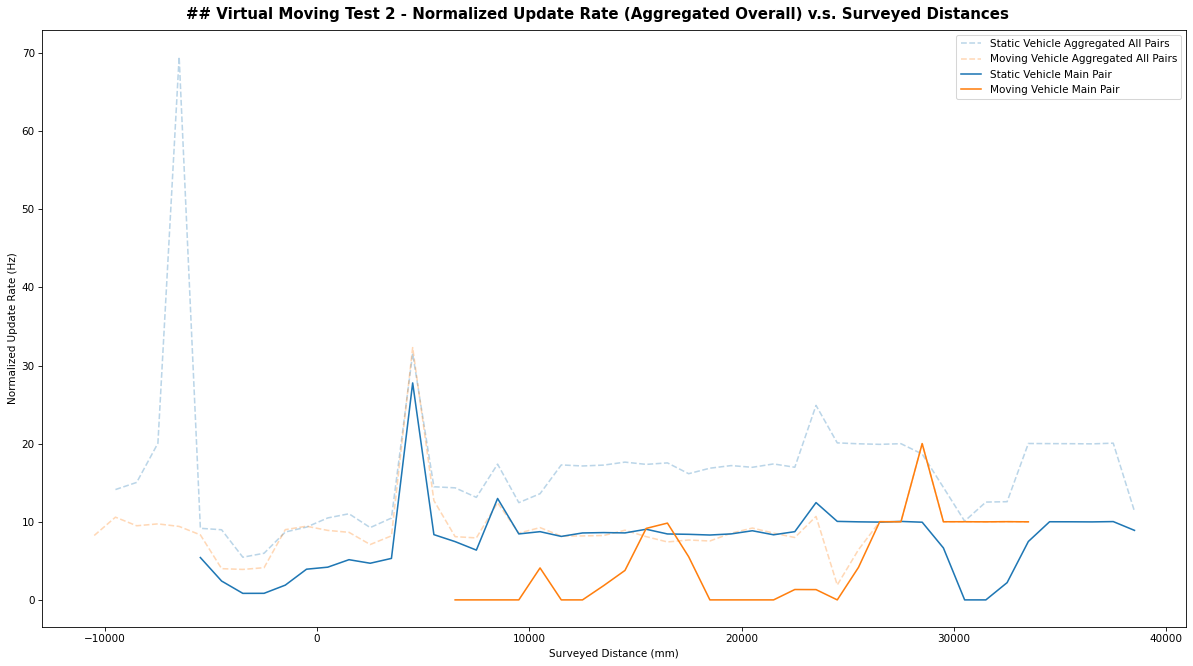

In [8]:
titlename = "## Virtual Moving Test 2 - Normalized Update Rate (Aggregated Overall) v.s. Surveyed Distances"
dist_binsize = 200 if not test_preset_map.get('dist_interval_size') else test_preset_map.get('dist_interval_size')
interval_idx_stats = defaultdict(dict)
for veh_dist_idx_df_list in [list_df_dist_idx_static, list_df_dist_idx_moving]:
    veh = veh_dist_idx_df_list[0]['Initiating Vehicle'].unique()[0]
    interval_idx_stats[veh]['aggregated'] = dist_interval_idx_df_by_veh_all_tests(veh_dist_idx_df_list, dist_binsize)
    interval_idx_stats[veh]['main'] = dist_interval_idx_df_by_veh_all_tests(  veh_dist_idx_df_list, 
                                                                                dist_binsize,
                                                                                test_preset_map[veh]['main_master'], 
                                                                                test_preset_map[veh]['master_slave_mapping'][test_preset_map[veh]['main_master']][0])
figure = plt.figure(figsize=(16, 9), dpi=test_preset_map['PLOTTING_DPI'])
figure.suptitle(titlename, fontsize='x-large', fontweight='bold')
plot_dist_idx_udpate_rate(      figure,
                                list_df_dist_idx_static,
                                list_df_dist_idx_moving,
                                STATIC_VEH,
                                MOVING_VEH,
                                test_preset_map,
                                dist_bin=dist_binsize)
plt.show()

## Virtual Moving Test 2 - Reporting Count Bar Chart v.s. Surveyed Distances

### Static Vehicle & Moving Vehicle

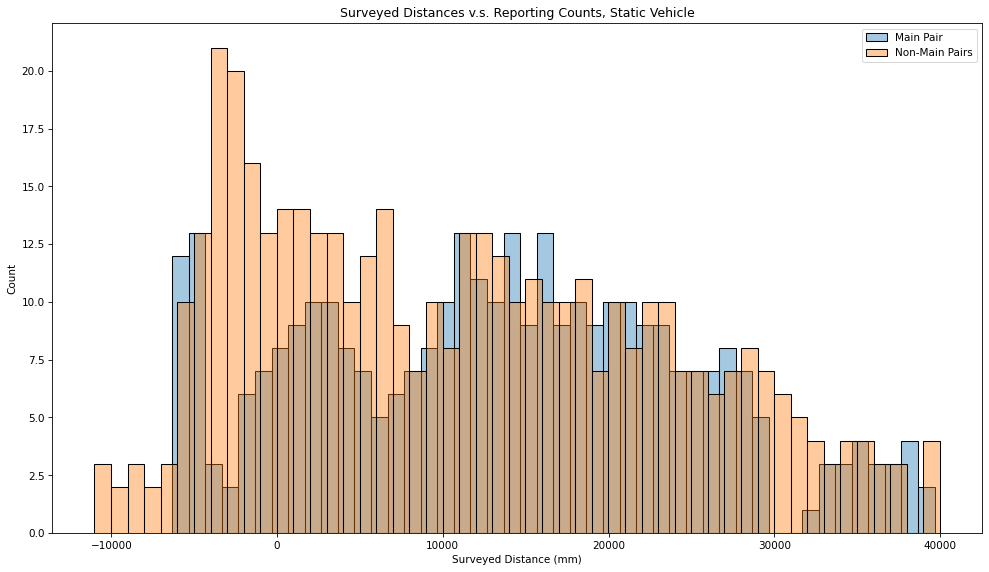

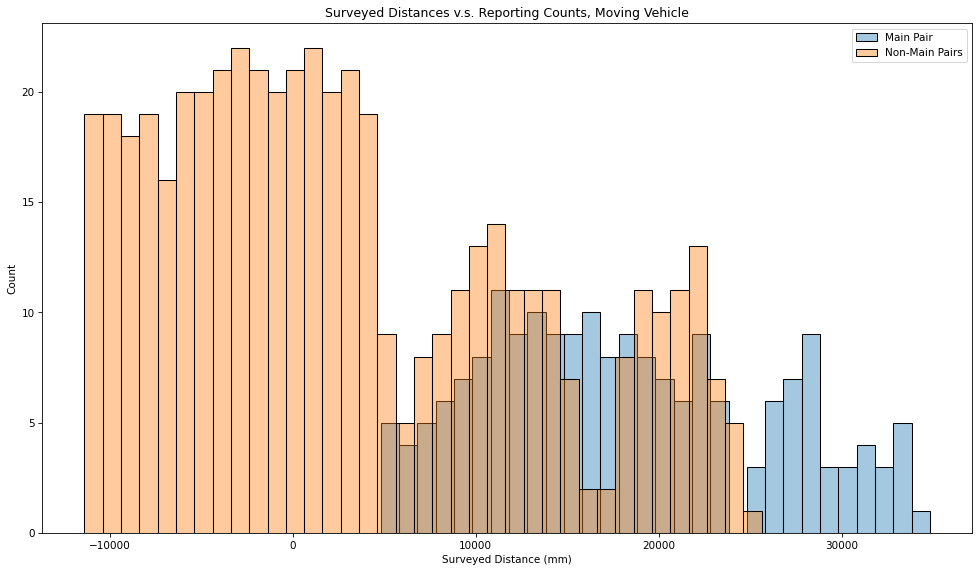

In [9]:
dist_bin = 1000

for df_veh_time_idx_all_tests in [df_all_static_stats_time_idx, df_all_moving_stats_time_idx]:
    if df_veh_time_idx_all_tests['Initiating Vehicle'].unique()[0] == STATIC_VEH:
        veh_name = "Static"
    if df_veh_time_idx_all_tests['Initiating Vehicle'].unique()[0] == MOVING_VEH:
        veh_name = "Moving"
    main_df = df_veh_time_idx_all_tests[
        (df_veh_time_idx_all_tests["Is Main Master"] == True) & 
        (df_veh_time_idx_all_tests["Is Main Slave"] == True)
    ]
    main_df = main_df[main_df.index.notnull()]

    non_main_df = df_veh_time_idx_all_tests[
        (df_veh_time_idx_all_tests["Is Main Master"] != True) | 
        (df_veh_time_idx_all_tests["Is Main Slave"] != True)
    ]
    non_main_df = non_main_df[non_main_df.index.notnull()]

    figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
    ax1 = figure.add_subplot(111)

    # Main Pair
    hist_1 = sns.histplot(data=main_df.reset_index(), 
                        x=main_df.reset_index()["Surveyed Distance (mm)"],
                        binwidth=dist_bin, 
                        ax=ax1, 
                        color="C0", 
                        alpha=0.4, 
                        label="Main Pair")

    # Non-Main Pairs
    hist_2 = sns.histplot(data=non_main_df.reset_index(), 
                        x=non_main_df.reset_index()["Surveyed Distance (mm)"],
                        binwidth=dist_bin, 
                        ax=ax1, 
                        color="C1", 
                        alpha=0.4, 
                        label="Non-Main Pairs")
    ax1.set_title("Surveyed Distances v.s. Reporting Counts, {} Vehicle".format(veh_name))
    ax1.legend()
plt.show()

## Heat Map of Data Reporting Points when Instant Update Rate Cannot Reach 10Hz

### Static Vehicle & Moving Vehicle

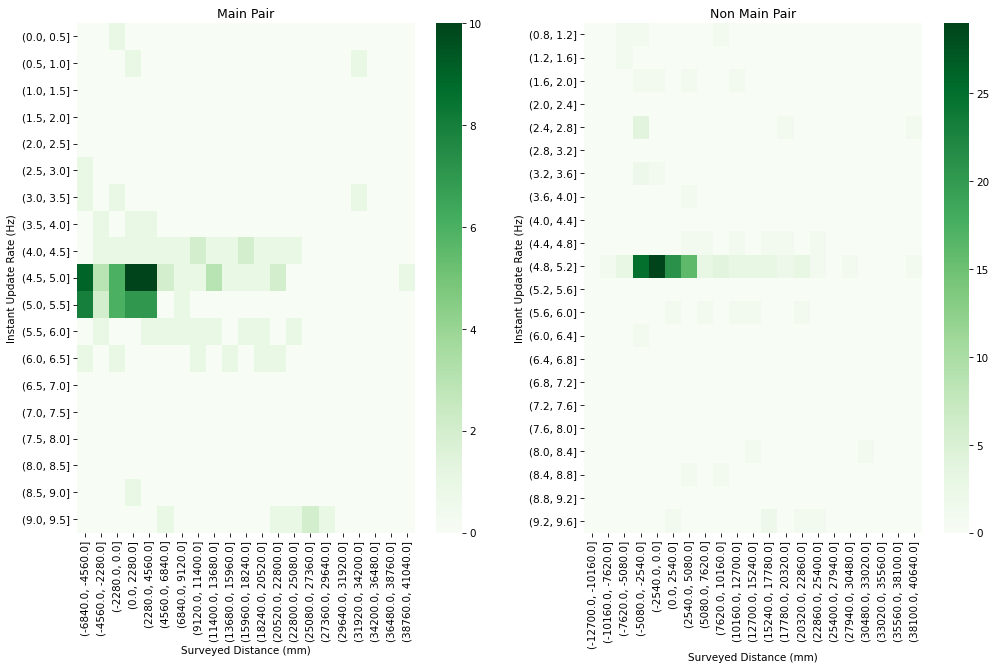

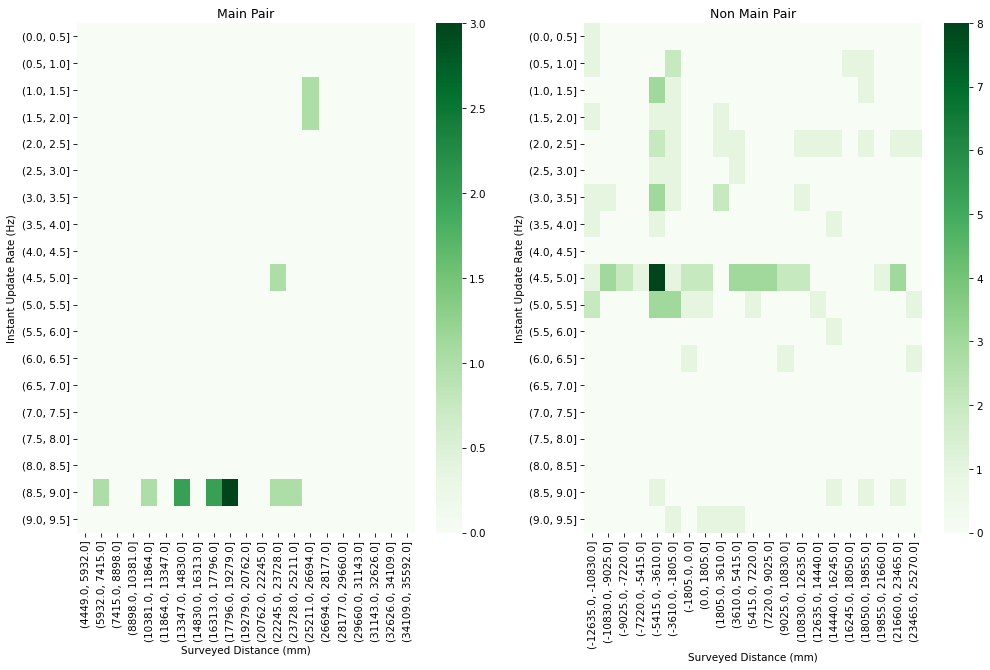

In [10]:
for df_veh_time_idx_all_tests in [df_all_static_stats_time_idx, df_all_moving_stats_time_idx]:
    if df_veh_time_idx_all_tests['Initiating Vehicle'].unique()[0] == STATIC_VEH:
        veh_name = "Static"
    if df_veh_time_idx_all_tests['Initiating Vehicle'].unique()[0] == MOVING_VEH:
        veh_name = "Moving"
    main_df = df_veh_time_idx_all_tests[
        (df_veh_time_idx_all_tests["Is Main Master"] == True) & 
        (df_veh_time_idx_all_tests["Is Main Slave"] == True)
    ]
    main_df = main_df[main_df.index.notnull()]

    non_main_df = df_veh_time_idx_all_tests[
        (df_veh_time_idx_all_tests["Is Main Master"] != True) | 
        (df_veh_time_idx_all_tests["Is Main Slave"] != True)
    ]
    non_main_df = non_main_df[non_main_df.index.notnull()]

    _veh_dist_notnull_main = main_df["Surveyed Distance (mm)"].dropna()
    _veh_hz_notnull_main = main_df["Instant Update Rate (Hz)"].dropna()
    _veh_dist_notnull_non_main = non_main_df["Surveyed Distance (mm)"].dropna()
    _veh_hz_notnull_non_main = non_main_df["Instant Update Rate (Hz)"].dropna()
    min_update_rate_regarded_as_normal = 9.9
    bin_count = 20

    dist_bin_main = round((max(_veh_dist_notnull_main) - min(_veh_dist_notnull_main)) / bin_count, 0)
    hz_bin_main = round((min_update_rate_regarded_as_normal - min(_veh_hz_notnull_main)) / bin_count, 1)

    dist_bin_non_main = round((max(_veh_dist_notnull_non_main) - min(_veh_dist_notnull_non_main)) / bin_count, 0)
    hz_bin_non_main = max(round((min_update_rate_regarded_as_normal - min(_veh_hz_notnull_non_main)) / bin_count, 1), 0.1)

    dist_bins_main = np.arange(dist_bin_main * (min(_veh_dist_notnull_main) // dist_bin_main), 
                            dist_bin_main * ((max(_veh_dist_notnull_main) + dist_bin_main) // dist_bin_main + 1), 
                            dist_bin_main)
    hz_bins_main = np.arange(hz_bin_main * (min(_veh_hz_notnull_main) // hz_bin_main), 
                            hz_bin_main * ((max(_veh_hz_notnull_main) + hz_bin_main) // hz_bin_main + 1), 
                            hz_bin_main)

    dist_bins_non_main = np.arange(dist_bin_non_main * (min(_veh_dist_notnull_non_main) // dist_bin_non_main), 
                                dist_bin_non_main * ((max(_veh_dist_notnull_non_main) + dist_bin_non_main) // dist_bin_non_main + 1), 
                                dist_bin_non_main)
    hz_bins_non_main = np.arange(hz_bin_non_main * (min(_veh_hz_notnull_non_main) // hz_bin_non_main), 
                                hz_bin_non_main * ((max(_veh_hz_notnull_non_main) + hz_bin_non_main) // hz_bin_non_main + 1), 
                                hz_bin_non_main)

    df_main_pair_assorted = pd.DataFrame(index=(main_df["Instant Update Rate (Hz)"]
                                                .dropna()
                                                .groupby(pd.cut(main_df["Instant Update Rate (Hz)"].dropna(), 
                                                                hz_bins_main))
                                                .count()
                                                .index),
                                        columns=(main_df["Surveyed Distance (mm)"]
                                                .dropna()
                                                .groupby(pd.cut(main_df["Surveyed Distance (mm)"].dropna(), 
                                                                dist_bins_main))
                                                .count()
                                                .index)
                                        ).replace(np.nan, 0)

    df_non_main_assorted = pd.DataFrame(index=(non_main_df["Instant Update Rate (Hz)"]
                                            .dropna()
                                            .groupby(pd.cut(non_main_df["Instant Update Rate (Hz)"].dropna(), 
                                                            hz_bins_non_main))
                                            .count()
                                            .index),
                                        columns=(non_main_df["Surveyed Distance (mm)"]
                                                .dropna()
                                                .groupby(pd.cut(non_main_df["Surveyed Distance (mm)"].dropna(), 
                                                                dist_bins_non_main))
                                                .count()
                                                .index)
                                        ).replace(np.nan, 0)

    for index, row in main_df.iterrows():
        if pd.isnull(row["Instant Update Rate (Hz)"]) or pd.isnull(row["Surveyed Distance (mm)"]):
            continue
        df_main_pair_assorted.iloc[
            df_main_pair_assorted.index.get_loc(row["Instant Update Rate (Hz)"]),
            df_main_pair_assorted.columns.get_loc(row["Surveyed Distance (mm)"])
        ] += 1
    for index, row in non_main_df.iterrows():
        if pd.isnull(row["Instant Update Rate (Hz)"]) or pd.isnull(row["Surveyed Distance (mm)"]):
            continue
        df_non_main_assorted.iloc[
            df_non_main_assorted.index.get_loc(row["Instant Update Rate (Hz)"]),
            df_non_main_assorted.columns.get_loc(row["Surveyed Distance (mm)"])
        ] += 1
    figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
    if not df_non_main_assorted.loc[
        [i.right < min_update_rate_regarded_as_normal for i in df_non_main_assorted.index.array]].empty:
        ax1 = figure.add_subplot(121)
        h1 = sns.heatmap(df_main_pair_assorted.loc[
        [i.right < min_update_rate_regarded_as_normal for i in df_main_pair_assorted.index.array]],
                    cmap="Greens")

        ax1.set_title("Main Pair")
        ax2 = figure.add_subplot(122)
        h2 = sns.heatmap(df_non_main_assorted.loc[
            [i.right < min_update_rate_regarded_as_normal for i in df_non_main_assorted.index.array]],
                        cmap="Greens")
        ax2.set_title("Non Main Pair")
    else:
        ax1 = figure.add_subplot(111)
        h1 = sns.heatmap(df_main_pair_assorted.loc[
        [i.right < min_update_rate_regarded_as_normal for i in df_main_pair_assorted.index.array]],
                    cmap="Greens")
        ax1.set_title("Main Pair (Non Main Pair Empty)")
plt.show()

In [11]:
virtual_moving_tests.keys()

dict_keys(['2021-05-25-13-00-19-v2-1-west', '2021-05-25-13-01-56-v2-1-east', '2021-05-25-13-07-12-v2-2-west-10mph', '2021-05-25-13-09-08-v2-2-east-15mph', '2021-05-25-13-10-51-v2-3-west-10mph', '2021-05-25-13-12-45-v2-3-east-10mph', '2021-05-25-13-14-27-v2-4-west-20mph', '2021-05-25-13-16-54-v2-4-east-20mph', '2021-05-25-13-24-09-v2-5-west-10mph', '2021-05-25-13-27-19-v2-5-east-15mph', '2021-05-25-13-30-54-v2-6-west-15mph', '2021-05-25-13-33-14-v2-6-east-25mph', '2021-05-25-13-39-32-v2-7-west-edgepush', '2021-05-25-13-42-27-v2-edgepush-seg', '2021-05-25-13-46-51-v2-8-edgepush-seg', '2021-05-25-13-48-43-v2-edgepush-seg', '2021-05-25-13-49-31-v2-edgepush-seg', '2021-05-25-13-51-49-v2-edgepush-seg', '2021-05-25-13-52-07-v2-9-east'])

In [12]:
virtual_moving_tests['2021-05-25-13-33-14-v2-6-east-25mph']

## Normalized Update Rate v.s. Relative/Absolute Relative Speed, Aggregated Pairs

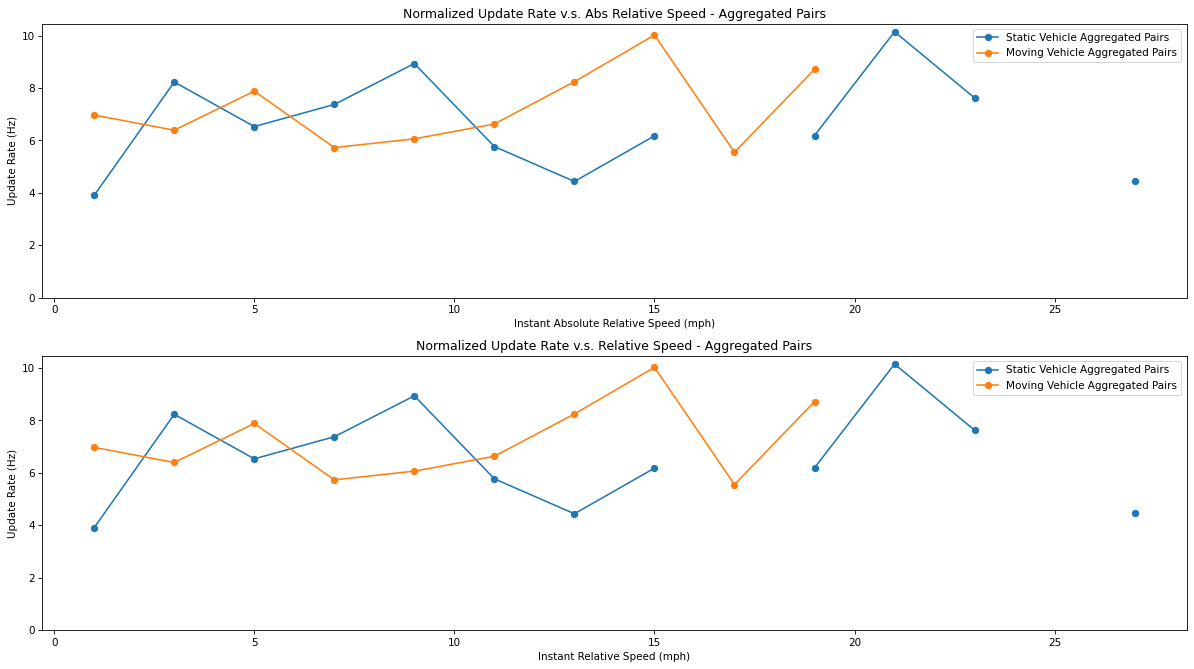

In [14]:
v_bin = 2
v_range = [-30, 30]



static_grouped_list_veh_idx = []
categorical_idx_static = None
for df in list_df_time_idx_static:
    df = df[df["Surveyed Distance (mm)"].notnull()]
    if df.shape[0] == 0:
        continue
    else: 
        assert df["Surveyed Distance (mm)"].dropna().is_monotonic_increasing \
            or df["Surveyed Distance (mm)"].dropna().is_monotonic_decreasing
        for master, slave_list in static_master_slave_mapping.items():
            for slave in slave_list:
                pairwise_df = df[(df["Initiating Master"] == master) & (df["Reporting Slave"] == slave)]
                if pairwise_df.index.empty:
                    continue
                pairwise_df = pairwise_df.set_index("Instant Speed by Marker (mph)")
                pairwise_df["Time Interval (s)"] = pairwise_df["Timestamp Norm (s)"].diff()
                pairwise_df = pairwise_df[(pairwise_df.index.notnull()) & (np.isfinite(pairwise_df.index))]
                if pairwise_df.index.empty:
                    continue
                bins = np.arange(v_bin * (min(pairwise_df.index) // v_bin), 
                                 v_bin * ((max(pairwise_df.index) + v_bin) // v_bin + 1), 
                                 v_bin)
                grouped_df = pd.DataFrame()
                grouped_df["duration"] = pairwise_df["Time Interval (s)"].groupby(pd.cut(pairwise_df.index, bins)).sum()
                grouped_df["reporting counts"] = pairwise_df["Timestamp Norm (s)"].groupby(
                    pd.cut(pairwise_df.index, bins)).count()
                grouped_df["Is Main Pair"] = (master == static_main_master) & \
                    (slave == static_master_slave_mapping[static_main_master][0])
                static_grouped_list_veh_idx.append(grouped_df)
                if categorical_idx_static is None:
                    categorical_idx_static = grouped_df.index
                else:
                    categorical_idx_static = categorical_idx_static.union(grouped_df.index)
                
static_df_counts_spd_idx = pd.DataFrame(index=categorical_idx_static, columns=['reporting counts', 'duration'])
static_df_counts_spd_idx['reporting counts'] = 0
static_df_counts_spd_idx['duration'] = 0
for df in static_grouped_list_veh_idx:
    df = df.reindex_like(static_df_counts_spd_idx).fillna(0)
    static_df_counts_spd_idx['reporting counts'] = static_df_counts_spd_idx['reporting counts'] + df['reporting counts']
    static_df_counts_spd_idx['duration'] = static_df_counts_spd_idx['duration'] + df['duration']
static_df_idx_min = static_df_counts_spd_idx.loc[static_df_counts_spd_idx["reporting counts"] >= 2].index.min()
static_df_idx_max = static_df_counts_spd_idx.loc[static_df_counts_spd_idx["reporting counts"] >= 2].index.max()
static_df_filtered = static_df_counts_spd_idx.loc[static_df_idx_min:static_df_idx_max]
    
moving_grouped_list_veh_idx = []
categorical_idx_moving = None
for df in list_df_time_idx_moving:
    df = df[df["Surveyed Distance (mm)"].notnull()]
    if df.shape[0] == 0:
        continue
    else: 
        assert df["Surveyed Distance (mm)"].dropna().is_monotonic_increasing \
            or df["Surveyed Distance (mm)"].dropna().is_monotonic_decreasing
        for master, slave_list in moving_master_slave_mapping.items():
            for slave in slave_list:
                pairwise_df = df[(df["Initiating Master"] == master) & (df["Reporting Slave"] == slave)]
                if df.index.empty:
                    continue
                pairwise_df = pairwise_df.set_index("Instant Speed by Marker (mph)")
                pairwise_df["Time Interval (s)"] = pairwise_df["Timestamp Norm (s)"].diff()
                pairwise_df = pairwise_df[(pairwise_df.index.notnull()) & (np.isfinite(pairwise_df.index))]
                if pairwise_df.index.empty:
                    continue
                bins = np.arange(v_bin * (min(pairwise_df.index) // v_bin), 
                                 v_bin * ((max(pairwise_df.index) + v_bin) // v_bin + 1), 
                                 v_bin)
                grouped_df = pd.DataFrame()
                grouped_df["duration"] = pairwise_df["Time Interval (s)"].groupby(pd.cut(pairwise_df.index, bins)).sum()
                grouped_df["reporting counts"] = pairwise_df["Timestamp Norm (s)"].groupby(
                    pd.cut(pairwise_df.index, bins)).count()
                grouped_df["Is Main Pair"] = (master == moving_main_master) & \
                    (slave == moving_master_slave_mapping[moving_main_master][0])
                moving_grouped_list_veh_idx.append(grouped_df)
                if categorical_idx_moving is None:
                    categorical_idx_moving = grouped_df.index
                else:
                    categorical_idx_moving = categorical_idx_moving.union(grouped_df.index)
                
moving_df_counts_spd_idx = pd.DataFrame(index=categorical_idx_moving, columns=['reporting counts', 'duration'])
moving_df_counts_spd_idx['reporting counts'] = 0
moving_df_counts_spd_idx['duration'] = 0
for df in moving_grouped_list_veh_idx:
    df = df.reindex_like(moving_df_counts_spd_idx).fillna(0)
    moving_df_counts_spd_idx['reporting counts'] = moving_df_counts_spd_idx['reporting counts'] + df['reporting counts']
    moving_df_counts_spd_idx['duration'] = moving_df_counts_spd_idx['duration'] + df['duration']
moving_df_idx_min = moving_df_counts_spd_idx.loc[moving_df_counts_spd_idx["reporting counts"] >= 2].index.min()
moving_df_idx_max = moving_df_counts_spd_idx.loc[moving_df_counts_spd_idx["reporting counts"] >= 2].index.max()
moving_df_filtered = moving_df_counts_spd_idx.loc[moving_df_idx_min:moving_df_idx_max]

# Plotting - Relative Abs Speed 
static_df_filtered['absmid'] = [abs(i.mid) for i in static_df_filtered.index.array]
_temp_df_static = static_df_filtered.reset_index(drop=True)
bins = np.arange(0, 
                 v_bin * ((max(_temp_df_static['absmid']) + v_bin) // v_bin + 1), 
                 v_bin)
static_df_filtered_abs_spd = pd.DataFrame()
static_df_filtered_abs_spd["reporting counts"] = _temp_df_static.groupby(
    pd.cut(_temp_df_static['absmid'], bins)).apply(lambda i:sum(i["reporting counts"]))
static_df_filtered_abs_spd["duration"] = _temp_df_static.groupby(
    pd.cut(_temp_df_static['absmid'], bins)).apply(lambda i:sum(i["duration"]))

moving_df_filtered['absmid'] = [abs(i.mid) for i in moving_df_filtered.index.array]
_temp_df_moving = moving_df_filtered.reset_index(drop=True)
bins = np.arange(0, 
                 v_bin * ((max(_temp_df_static['absmid']) + v_bin) // v_bin + 1), 
                 v_bin)
moving_df_filtered_abs_spd = pd.DataFrame()
moving_df_filtered_abs_spd["reporting counts"] = _temp_df_moving.groupby(
    pd.cut(_temp_df_moving['absmid'], bins)).apply(lambda i:sum(i["reporting counts"]))
moving_df_filtered_abs_spd["duration"] = _temp_df_moving.groupby(
    pd.cut(_temp_df_moving['absmid'], bins)).apply(lambda i:sum(i["duration"]))

static_df_filtered_abs_spd = static_df_filtered_abs_spd.loc[
    [v_range[0] < i.mid < v_range[1] for i in static_df_filtered_abs_spd.index.array]]
moving_df_filtered_abs_spd = moving_df_filtered_abs_spd.loc[
    [v_range[0] < i.mid < v_range[1] for i in moving_df_filtered_abs_spd.index.array]]

static_df_filtered_signed_spd = static_df_filtered.loc[
    [v_range[0] < i.mid < v_range[1] for i in static_df_filtered.index.array]]
moving_df_filtered_signed_spd = moving_df_filtered.loc[
    [v_range[0] < i.mid < v_range[1] for i in moving_df_filtered.index.array]]

figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
ax1 = figure.add_subplot(211)
ax1.plot([i.mid for i in (static_df_filtered_abs_spd['reporting counts'] / static_df_filtered_abs_spd['duration']).index.array], 
        static_df_filtered_abs_spd['reporting counts'] / static_df_filtered_abs_spd['duration'],
        label="Static Vehicle Aggregated Pairs", marker="o", color="C0")
ax1.plot([i.mid for i in (moving_df_filtered_abs_spd['reporting counts'] / moving_df_filtered_abs_spd['duration']).index.array], 
        moving_df_filtered_abs_spd['reporting counts'] / moving_df_filtered_abs_spd['duration'],
        label="Moving Vehicle Aggregated Pairs", marker="o", color="C1")
ax1.legend()
ax1.set_ylabel("Update Rate (Hz)")
ax1.set_xlabel("Instant Absolute Relative Speed (mph)")
ax1.set_title("Normalized Update Rate v.s. Abs Relative Speed - Aggregated Pairs")
ax1.set_ylim(bottom=0)

ax2 = figure.add_subplot(212)
ax2.plot([i.mid for i in 
          (static_df_filtered_signed_spd['reporting counts'] / static_df_filtered_signed_spd['duration']).index.array], 
         static_df_filtered_signed_spd['reporting counts'] / static_df_filtered_signed_spd['duration'],
         label="Static Vehicle Aggregated Pairs", marker="o", color="C0")
ax2.plot([i.mid for i in 
          (moving_df_filtered_signed_spd['reporting counts'] / moving_df_filtered_signed_spd['duration']).index.array], 
         moving_df_filtered_signed_spd['reporting counts'] / moving_df_filtered_signed_spd['duration'],
         label="Moving Vehicle Aggregated Pairs", marker="o", color="C1")
ax2.legend()
ax2.set_ylabel("Update Rate (Hz)")
ax2.set_xlabel("Instant Relative Speed (mph)")
ax2.set_title("Normalized Update Rate v.s. Relative Speed - Aggregated Pairs")
ax2.set_ylim(bottom=0)

figure.tight_layout(pad=1.0)
plt.show()

## Normalized Update Rate v.s. Relative/Absolute Relative Speed, Main Pair

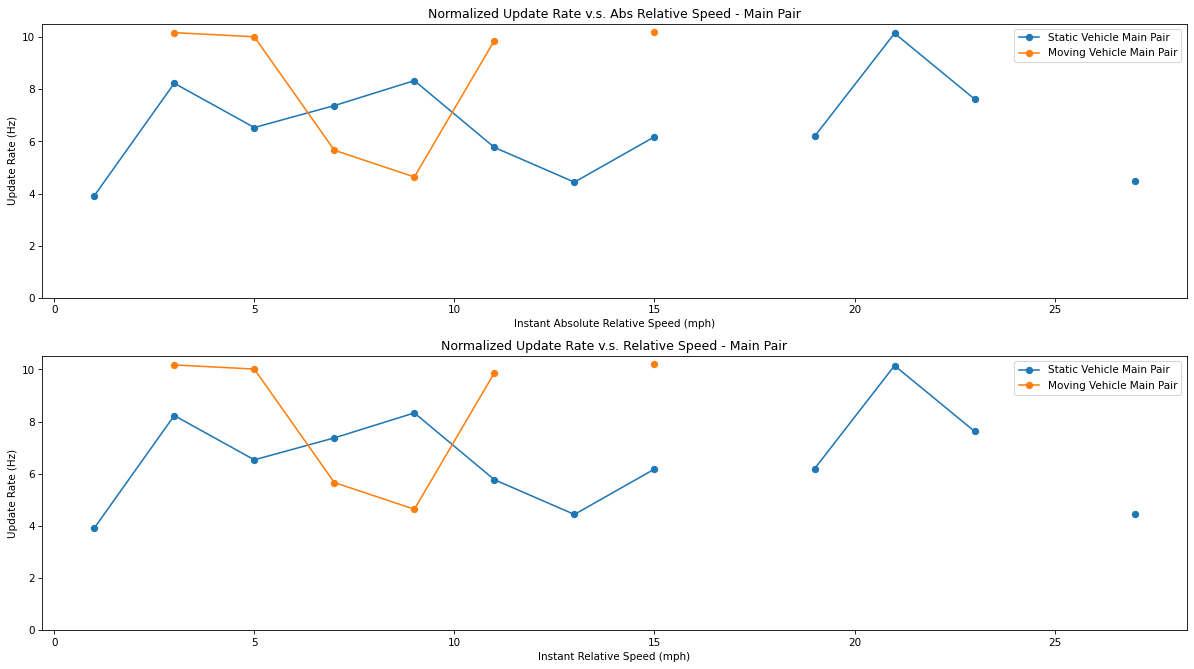

In [15]:
static_grouped_list_veh_idx_main_pair = []
categorical_idx_static_main_pair = None
for df in list_df_time_idx_static:
    df = df[df["Surveyed Distance (mm)"].notnull()]
    if df.shape[0] == 0:
        continue
    else: 
        assert df["Surveyed Distance (mm)"].dropna().is_monotonic_increasing \
            or df["Surveyed Distance (mm)"].dropna().is_monotonic_decreasing
        # Main Pair
        mainpair_df = df[(df["Initiating Master"] == static_main_master) & (df["Reporting Slave"] == static_focusing_slaves[0])]
        if mainpair_df.index.empty:
            continue
        mainpair_df = mainpair_df.set_index("Instant Speed by Marker (mph)")
        mainpair_df["Time Interval (s)"] = mainpair_df["Timestamp Norm (s)"].diff()
        mainpair_df = mainpair_df[(mainpair_df.index.notnull()) & (np.isfinite(mainpair_df.index))]
        if mainpair_df.index.empty:
            continue
        bins = np.arange(v_bin * (min(mainpair_df.index) // v_bin), 
                         v_bin * ((max(mainpair_df.index) + v_bin) // v_bin + 1), 
                         v_bin)
        grouped_df = pd.DataFrame()
        grouped_df["duration"] = mainpair_df["Time Interval (s)"].groupby(pd.cut(mainpair_df.index, bins)).sum()
        grouped_df["reporting counts"] = mainpair_df["Timestamp Norm (s)"].groupby(
            pd.cut(mainpair_df.index, bins)).count()
        grouped_df["Is Main Pair"] = (master == static_main_master) & \
            (slave == static_master_slave_mapping[static_main_master][0])
        static_grouped_list_veh_idx_main_pair.append(grouped_df)
        if categorical_idx_static_main_pair is None:
            categorical_idx_static_main_pair = grouped_df.index
        else:
            categorical_idx_static_main_pair = categorical_idx_static_main_pair.union(grouped_df.index)
                
static_df_counts_spd_idx_main_pair = pd.DataFrame(index=categorical_idx_static_main_pair, columns=['reporting counts', 'duration'])
static_df_counts_spd_idx_main_pair['reporting counts'] = 0
static_df_counts_spd_idx_main_pair['duration'] = 0
for df in static_grouped_list_veh_idx_main_pair:
    df = df.reindex_like(static_df_counts_spd_idx_main_pair).fillna(0)
    static_df_counts_spd_idx_main_pair['reporting counts'] = static_df_counts_spd_idx_main_pair['reporting counts'] + df['reporting counts']
    static_df_counts_spd_idx_main_pair['duration'] = static_df_counts_spd_idx_main_pair['duration'] + df['duration']
static_df_idx_min = static_df_counts_spd_idx_main_pair.loc[static_df_counts_spd_idx_main_pair["reporting counts"] >= 2].index.min()
static_df_idx_max = static_df_counts_spd_idx_main_pair.loc[static_df_counts_spd_idx_main_pair["reporting counts"] >= 2].index.max()
static_df_filtered_main_pair = static_df_counts_spd_idx_main_pair.loc[static_df_idx_min:static_df_idx_max]
    
moving_grouped_list_veh_idx_main_pair = []
categorical_idx_moving_main_pair = None
for df in list_df_time_idx_moving:
    df = df[df["Surveyed Distance (mm)"].notnull()]
    if df.shape[0] == 0:
        continue
    else: 
        assert df["Surveyed Distance (mm)"].dropna().is_monotonic_increasing \
            or df["Surveyed Distance (mm)"].dropna().is_monotonic_decreasing
        # Main Pair
        mainpair_df = df[(df["Initiating Master"] == moving_main_master) & (df["Reporting Slave"] == moving_focusing_slaves[0])]
        if df.index.empty:
            continue
        mainpair_df = mainpair_df.set_index("Instant Speed by Marker (mph)")
        mainpair_df["Time Interval (s)"] = mainpair_df["Timestamp Norm (s)"].diff()
        mainpair_df = mainpair_df[(mainpair_df.index.notnull()) & (np.isfinite(mainpair_df.index))]
        if mainpair_df.index.empty:
            continue
        bins = np.arange(v_bin * (min(mainpair_df.index) // v_bin), 
                         v_bin * ((max(mainpair_df.index) + v_bin) // v_bin + 1), 
                         v_bin)
        grouped_df = pd.DataFrame()
        grouped_df["duration"] = mainpair_df["Time Interval (s)"].groupby(pd.cut(mainpair_df.index, bins)).sum()
        grouped_df["reporting counts"] = mainpair_df["Timestamp Norm (s)"].groupby(
            pd.cut(mainpair_df.index, bins)).count()
        grouped_df["Is Main Pair"] = (master == moving_main_master) & \
            (slave == moving_master_slave_mapping[moving_main_master][0])
        moving_grouped_list_veh_idx_main_pair.append(grouped_df)
        if categorical_idx_moving_main_pair is None:
            categorical_idx_moving_main_pair = grouped_df.index
        else:
            categorical_idx_moving_main_pair = categorical_idx_moving_main_pair.union(grouped_df.index)
                
moving_df_counts_spd_idx_main_pair = pd.DataFrame(index=categorical_idx_moving_main_pair, columns=['reporting counts', 'duration'])
moving_df_counts_spd_idx_main_pair['reporting counts'] = 0
moving_df_counts_spd_idx_main_pair['duration'] = 0
for df in moving_grouped_list_veh_idx_main_pair:
    df = df.reindex_like(moving_df_counts_spd_idx_main_pair).fillna(0)
    moving_df_counts_spd_idx_main_pair['reporting counts'] = moving_df_counts_spd_idx_main_pair['reporting counts'] + df['reporting counts']
    moving_df_counts_spd_idx_main_pair['duration'] = moving_df_counts_spd_idx_main_pair['duration'] + df['duration']
moving_df_idx_min = moving_df_counts_spd_idx_main_pair.loc[moving_df_counts_spd_idx_main_pair["reporting counts"] >= 2].index.min()
moving_df_idx_max = moving_df_counts_spd_idx_main_pair.loc[moving_df_counts_spd_idx_main_pair["reporting counts"] >= 2].index.max()
moving_df_filtered_main_pair = moving_df_counts_spd_idx_main_pair.loc[moving_df_idx_min:moving_df_idx_max]

# Plotting - Relative Abs Speed 
static_df_filtered_main_pair['absmid'] = [abs(i.mid) for i in static_df_filtered_main_pair.index.array]
_temp_df_static = static_df_filtered_main_pair.reset_index(drop=True)
bins = np.arange(0, 
                 v_bin * ((max(_temp_df_static['absmid']) + v_bin) // v_bin + 1), 
                 v_bin)
static_df_filtered_main_pair_abs_spd = pd.DataFrame()
static_df_filtered_main_pair_abs_spd["reporting counts"] = _temp_df_static.groupby(
    pd.cut(_temp_df_static['absmid'], bins)).apply(lambda i:sum(i["reporting counts"]))
static_df_filtered_main_pair_abs_spd["duration"] = _temp_df_static.groupby(
    pd.cut(_temp_df_static['absmid'], bins)).apply(lambda i:sum(i["duration"]))

moving_df_filtered_main_pair['absmid'] = [abs(i.mid) for i in moving_df_filtered_main_pair.index.array]
_temp_df_moving = moving_df_filtered_main_pair.reset_index(drop=True)
bins = np.arange(0, 
                 v_bin * ((max(_temp_df_static['absmid']) + v_bin) // v_bin + 1), 
                 v_bin)
moving_df_filtered_main_pair_abs_spd = pd.DataFrame()
moving_df_filtered_main_pair_abs_spd["reporting counts"] = _temp_df_moving.groupby(
    pd.cut(_temp_df_moving['absmid'], bins)).apply(lambda i:sum(i["reporting counts"]))
moving_df_filtered_main_pair_abs_spd["duration"] = _temp_df_moving.groupby(
    pd.cut(_temp_df_moving['absmid'], bins)).apply(lambda i:sum(i["duration"]))

static_df_filtered_main_pair_abs_spd = static_df_filtered_main_pair_abs_spd.loc[
    [v_range[0] < i.mid < v_range[1] for i in static_df_filtered_main_pair_abs_spd.index.array]]
moving_df_filtered_main_pair_abs_spd = moving_df_filtered_main_pair_abs_spd.loc[
    [v_range[0] < i.mid < v_range[1] for i in moving_df_filtered_main_pair_abs_spd.index.array]]

# Plotting - Relative Signed Speed 
static_df_filtered_main_pair_signed_spd = static_df_filtered_main_pair.loc[
    [v_range[0] < i.mid < v_range[1] for i in static_df_filtered_main_pair.index.array]]
moving_df_filtered_main_pair_signed_spd = moving_df_filtered_main_pair.loc[
    [v_range[0] < i.mid < v_range[1] for i in moving_df_filtered_main_pair.index.array]]

figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
ax1 = figure.add_subplot(211)
ax1.plot([i.mid for i in (static_df_filtered_main_pair_abs_spd['reporting counts'] / static_df_filtered_main_pair_abs_spd['duration']).index.array], 
       static_df_filtered_main_pair_abs_spd['reporting counts'] / static_df_filtered_main_pair_abs_spd['duration'],
       label="Static Vehicle Main Pair", marker="o", color="C0")
ax1.plot([i.mid for i in (moving_df_filtered_main_pair_abs_spd['reporting counts'] / moving_df_filtered_main_pair_abs_spd['duration']).index.array], 
       moving_df_filtered_main_pair_abs_spd['reporting counts'] / moving_df_filtered_main_pair_abs_spd['duration'],
       label="Moving Vehicle Main Pair", marker="o", color="C1")
ax1.legend()
ax1.set_ylabel("Update Rate (Hz)")
ax1.set_xlabel("Instant Absolute Relative Speed (mph)")
ax1.set_title("Normalized Update Rate v.s. Abs Relative Speed - Main Pair")
ax1.set_ylim(bottom=0)

ax2 = figure.add_subplot(212)
ax2.plot([i.mid for i in 
          (static_df_filtered_main_pair_signed_spd['reporting counts'] / static_df_filtered_main_pair_signed_spd['duration']).index.array], 
         static_df_filtered_main_pair_signed_spd['reporting counts'] / static_df_filtered_main_pair_signed_spd['duration'],
         label="Static Vehicle Main Pair", marker="o", color="C0")
ax2.plot([i.mid for i in 
          (moving_df_filtered_main_pair_signed_spd['reporting counts'] / moving_df_filtered_main_pair_signed_spd['duration']).index.array], 
         moving_df_filtered_main_pair_signed_spd['reporting counts'] / moving_df_filtered_main_pair_signed_spd['duration'],
         label="Moving Vehicle Main Pair", marker="o", color="C1")
ax2.legend()
ax2.set_ylabel("Update Rate (Hz)")
ax2.set_xlabel("Instant Relative Speed (mph)")
ax2.set_title("Normalized Update Rate v.s. Relative Speed - Main Pair")
ax2.set_ylim(bottom=0)

figure.tight_layout(pad=1.0)
plt.show()

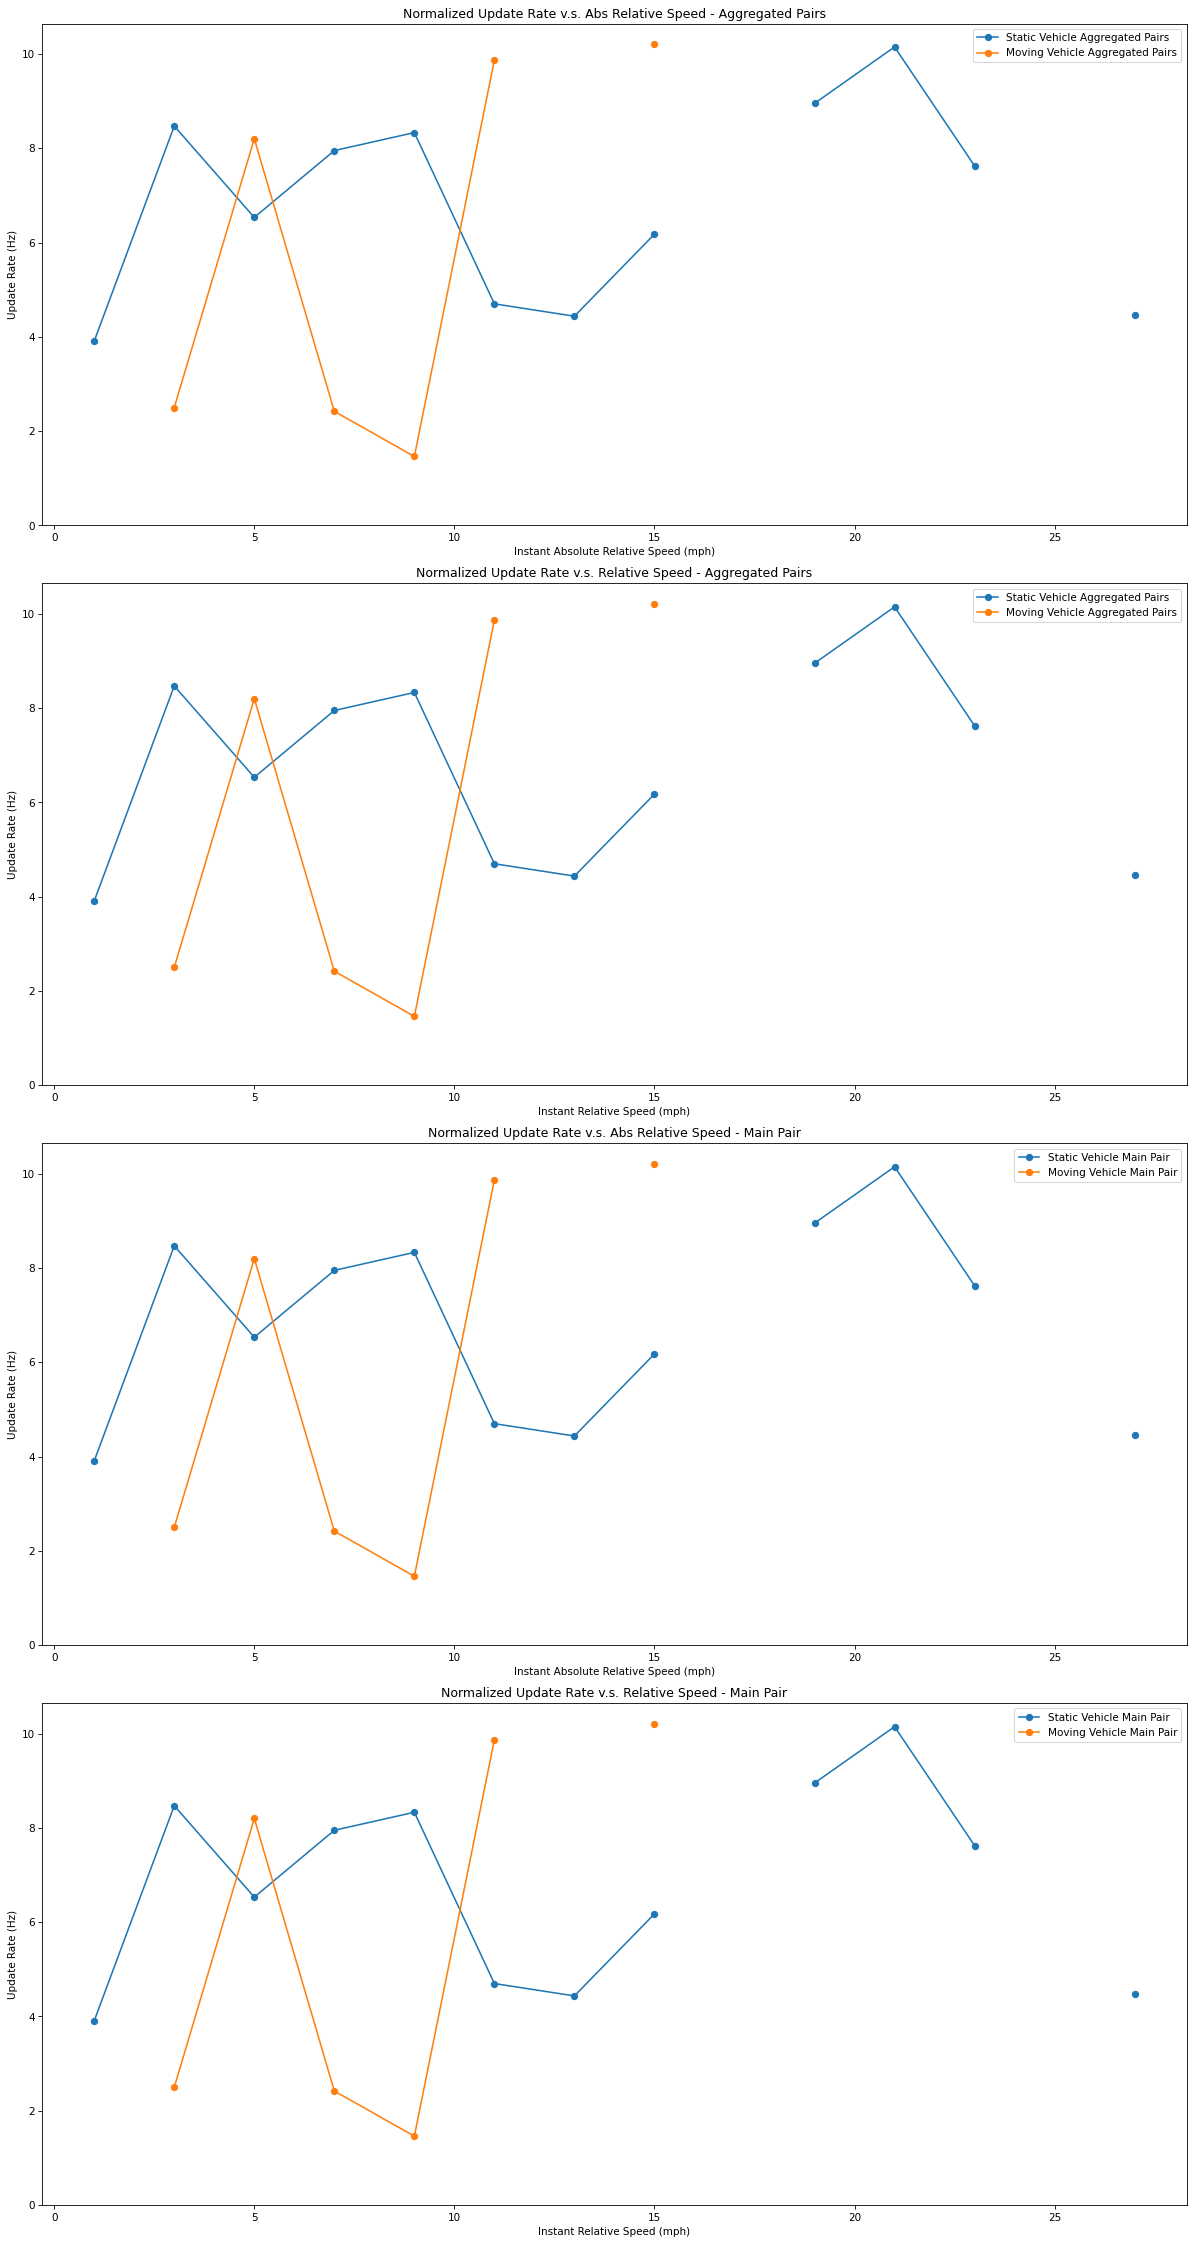

In [17]:
spd_binsize = 2 if not test_preset_map.get('spd_interval_size') else test_preset_map.get('spd_interval_size')
figure = plt.figure(figsize=(16, 30), dpi=test_preset_map['PLOTTING_DPI'])
plot_spd_idx_udpate_rate(   figure,
                            list_df_spd_idx_static,
                            list_df_spd_idx_moving,
                            STATIC_VEH,
                            MOVING_VEH,
                            test_preset_map,
                            spd_binsize=spd_binsize,
                            spd_range=[-30, 30])
plt.show()